In [32]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [33]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float

    summary: str

In [34]:
graph = StateGraph(BatsmanState)

In [35]:
def calculate_sr(state: BatsmanState):
    if state['balls'] == 0:
        return 0.0
    
    sr = (state['runs'] / state['balls']) * 100
    return {'sr':sr}


def calculate_bpb(state: BatsmanState):
    if state['balls'] == 0:
        return 0.0
    bpb = state['balls'] / (state['fours'] + state['sixes'])
    return {'bpb': bpb}


def calculate_boundary_percent(state: BatsmanState):
    if state['runs'] == 0:
        return 0.0
    total_boundaries_runs = state['fours']*4 + state['sixes']*6
    boundary_percent = (total_boundaries_runs / state['runs']) * 100
    return {'boundary_percent': boundary_percent}


def summary(state: BatsmanState):
    summary=f"""
Strike Rate: {state['sr']:.2f} \n
Balls per Boundary: {state['bpb']:.2f} \n
Boundary Percentage: {state['boundary_percent']:.2f} \n
"""
    return {'summary': summary}

In [36]:
graph.add_node('callable_sr', calculate_sr)
graph.add_node('callable_bpb', calculate_bpb)
graph.add_node('callable_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'callable_sr')
graph.add_edge(START, 'callable_bpb')
graph.add_edge(START, 'callable_boundary_percent')

graph.add_edge('callable_sr', 'summary')
graph.add_edge('callable_bpb', 'summary')
graph.add_edge('callable_boundary_percent', 'summary')

graph.add_edge('summary', END)

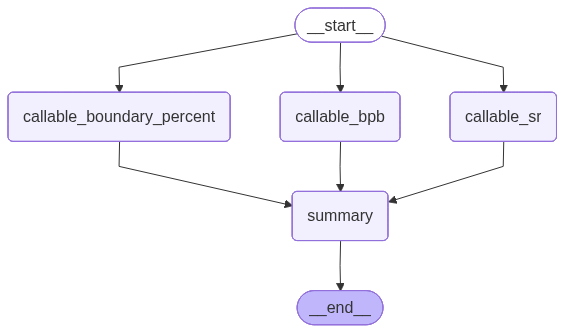

In [37]:
workflow = graph.compile()
workflow

In [38]:
initial_state = {
    'runs': 100,
    'balls': 60,
    'fours': 10,
    'sixes': 5
}

final_state = workflow.invoke(initial_state)

In [39]:
final_state

{'runs': 100,
 'balls': 60,
 'fours': 10,
 'sixes': 5,
 'sr': 166.66666666666669,
 'bpb': 4.0,
 'boundary_percent': 70.0,
 'summary': '\nStrike Rate: 166.67 \n\nBalls per Boundary: 4.00 \n\nBoundary Percentage: 70.00 \n\n'}